# Experiment 2: NGRC Analysis of the Recharge Oscillator

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from pathlib import Path

In [2]:
# Output directories

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "ro"

LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
R_DEFAULT = 0.25

def run_experiment(dt=0.025, ridge_param=2.5e-6, k=1, R=R_DEFAULT):

    # Parameters

    warmup = 5.0
    traintime = 10.0
    testtime = 50.0
    evaltime = 10.0

    maxtime = warmup + traintime + testtime

    warmup_pts = round(warmup/dt)
    traintime_pts = round(traintime/dt)

    warmtrain_pts = warmup_pts + traintime_pts

    testtime_pts = round(testtime/dt)
    maxtime_pts = round(maxtime/dt)
    evaltime_pts = round(evaltime/dt)

    # NVAR dimensions

    d = 2

    dlin = d*k
    dnonlin = dlin*(dlin+1)//2

    dtot = 1 + dlin + dnonlin

    t_eval = np.linspace(0, maxtime, maxtime_pts+1)

    # Recharge Oscillator

    F1, F2, eps = 1.0, 1.0, 0.5

    def recharge_oscillator(t, state):

        T, h = state

        dT = R*T + F1*h
        dh = -eps*h - F2*T

        return [dT, dh]

    ro_soln = solve_ivp(
        recharge_oscillator,
        (0, maxtime),
        [1.0, 0.0],
        t_eval=t_eval,
        method="RK23",
    )

    total_var = np.var(ro_soln.y)

    # Linear features

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):

        for j in range(delay, maxtime_pts):

            x[d*delay:d*(delay+1), j] = ro_soln.y[:, j-delay]

    # Training feature matrix

    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin+1, :] = x[:, warmup_pts-1:warmtrain_pts-1]

    cnt = 0

    for i in range(dlin):

        for j in range(i, dlin):

            out_train[dlin+1+cnt, :] = (
                x[i, warmup_pts-1:warmtrain_pts-1]
                * x[j, warmup_pts-1:warmtrain_pts-1]
            )

            cnt += 1

    # Training target

    Y = (
        x[:d, warmup_pts:warmtrain_pts]
        - x[:d, warmup_pts-1:warmtrain_pts-1]
    )

    # Ridge regression

    W_out = (
        Y @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param*np.identity(dtot)
        )
    )

    # Training prediction

    x_predict = (
        x[:d, warmup_pts-1:warmtrain_pts-1]
        + W_out @ out_train
    )

    train_nrmse = np.sqrt(
        np.mean(
            (
                x[:d, warmup_pts:warmtrain_pts]
                - x_predict
            )**2
        ) / total_var
    )

    # Autonomous prediction

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))

    x_test[:, 0] = x[:, warmtrain_pts-1]

    for j in range(testtime_pts-1):

        out_test[1:dlin+1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):

            for col in range(row, dlin):

                out_test[dlin+1+cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        x_test[d:dlin, j+1] = x_test[:dlin-d, j]

        x_test[:d, j+1] = (
            x_test[:d, j]
            + W_out @ out_test
        )

    # Test NRMSE

    true_segment = x[
        :d,
        warmtrain_pts-1:
        warmtrain_pts+evaltime_pts-1
    ]

    pred_segment = x_test[
        :d,
        :evaltime_pts
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (
                true_segment
                - pred_segment
            )**2
        ) / total_var
    )

    return {
        "dt": dt,
        "R": R,
        "k": k,
        "ridge": ridge_param,
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "W_out": W_out,
        "x_test": x_test,
        "true_test": x[
            :d,
            warmtrain_pts-1:
            warmtrain_pts+testtime_pts-1
        ],
    }

In [4]:
def build_labels(d=2, k=1):

    variables = ["T", "h"]

    linear_labels = []

    for delay in range(k):

        for var in variables:

            if delay == 0:
                linear_labels.append(f"{var}(t)")
            else:
                linear_labels.append(
                    f"{var}(t-{delay})"
                )

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):

            labels.append(
                f"{linear_labels[i]}*{linear_labels[j]}"
            )

    return labels

In [5]:
R_values = [0.25, 0.5, 0.75]

dt_values = [
    0.001,
    0.0025,
    0.005,
    0.01,
    0.025,
    0.05,
    0.06,
    0.07,
    0.08,
    0.09,
    0.1,
]

labels = build_labels(d=2, k=1)

In [6]:
all_results = []

for R in R_values:

    results = [
        run_experiment(
            dt=dt,
            ridge_param=2.5e-6,
            k=1,
            R=R,
        )
        for dt in dt_values
    ]

    all_results.extend(results)

print(f"Completed {len(all_results)} runs")

Completed 33 runs


In [7]:
rows = []

for result in all_results:

    W = result["W_out"]

    for eq, equation in enumerate(["dT", "dh"]):

        row = {
            "R": result["R"],
            "dt": result["dt"],
            "equation": equation,
            "train_nrmse": result["train_nrmse"],
            "test_nrmse": result["test_nrmse"],
        }

        for i, label in enumerate(labels):

            row[label] = W[eq, i]

        rows.append(row)

weights_df = pd.DataFrame(rows)

# weights_df.to_csv( "weights_analysis_ro_k1_dt_study.csv", index=False, )

weights_df.head()

,R,dt,equation,train_nrmse,test_nrmse,1,T(t),h(t),T(t)*T(t),T(t)*h(t),h(t)*h(t)
0,0.25,0.0010,dT,9.423539e-07,0.0001,4.418381e-09,0.000249,0.001000,2.535192e-07,3.811921e-07,-3.386394e-07
1,0.25,0.0010,dh,9.423539e-07,0.0001,-1.305311e-08,-0.000999,-0.000501,-3.779425e-07,-6.539724e-07,6.181100e-07
2,0.25,0.0025,dT,2.355292e-06,0.0001,1.088192e-08,0.000620,0.002499,6.340035e-07,9.523684e-07,-8.428808e-07
3,0.25,0.0025,dh,2.355292e-06,0.0001,-3.261768e-08,-0.002498,-0.001254,-9.440900e-07,-1.636388e-06,1.542110e-06
4,0.25,0.0050,dT,4.708168e-06,0.0001,2.119658e-08,0.001233,0.004997,1.268895e-06,1.902430e-06,-1.673219e-06


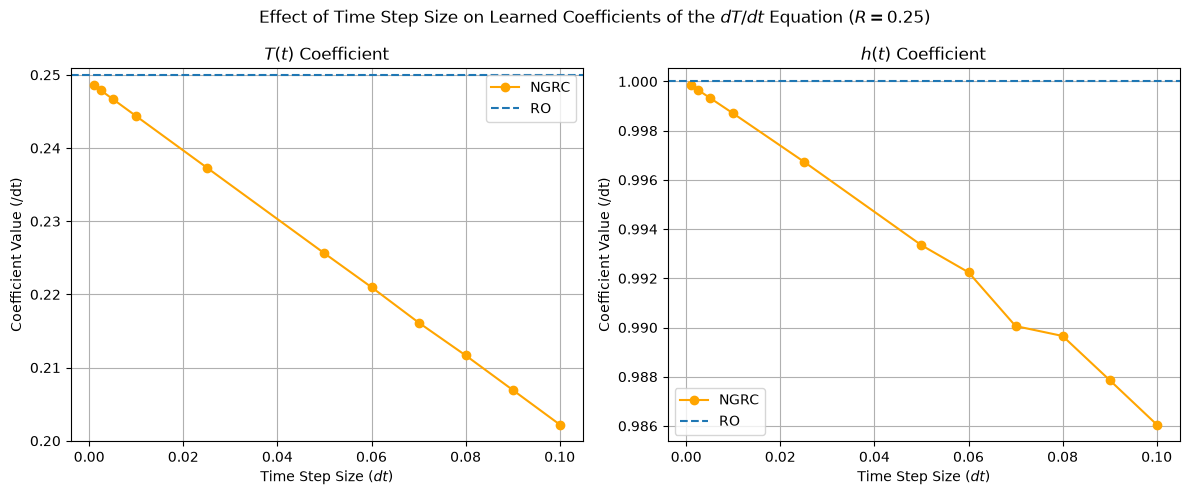

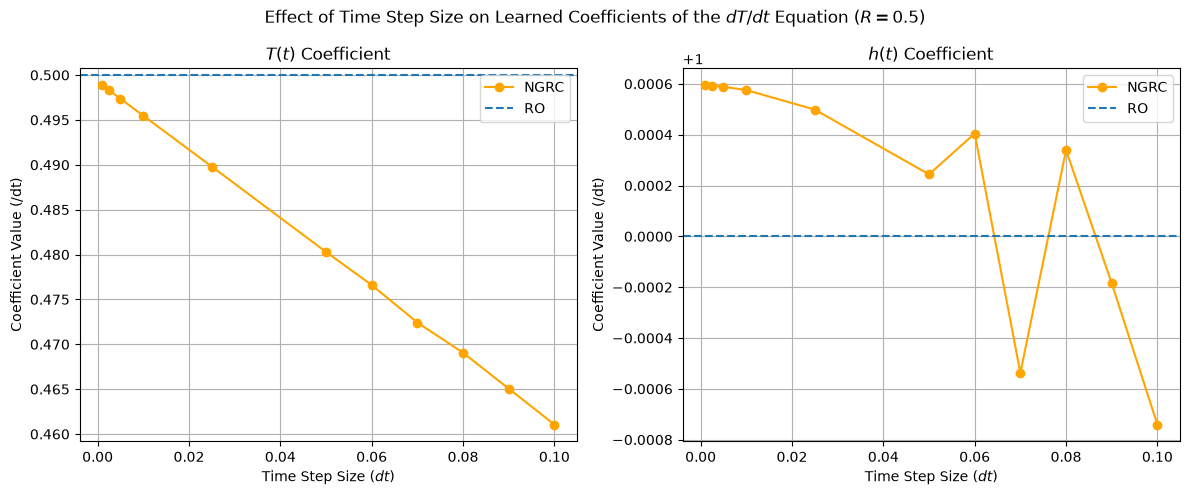

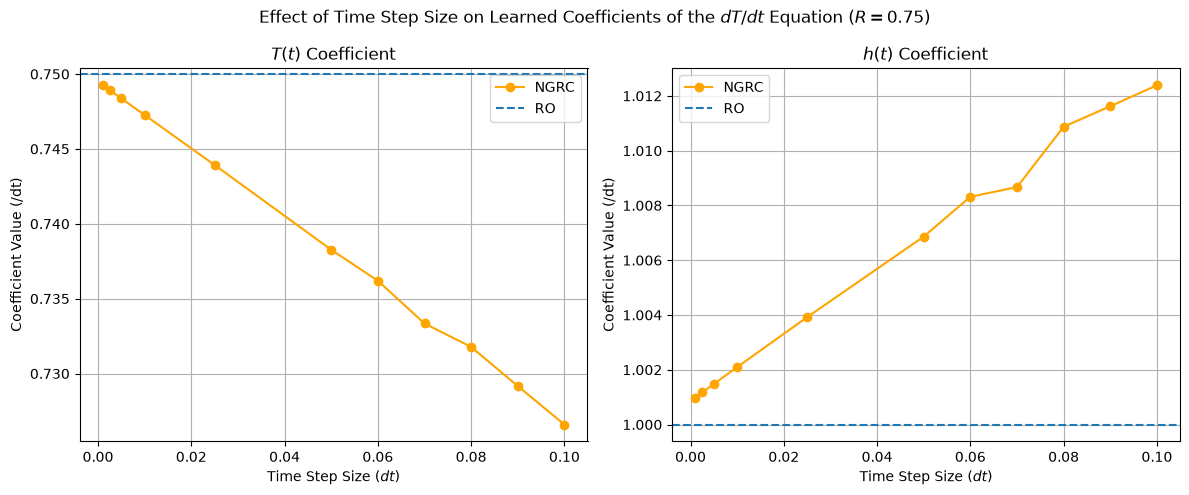

In [8]:
for R in R_values:

    weights_dT = weights_df[
        (weights_df["equation"] == "dT")
        & (weights_df["R"] == R)
    ].copy()

    weights_dT["NGRC T(t)/dt"] = (
        weights_dT["T(t)"] / weights_dT["dt"]
    )

    weights_dT["NGRC h(t)/dt"] = (
        weights_dT["h(t)"] / weights_dT["dt"]
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        sharex=True
    )

    # T coefficient

    axes[0].plot(
        weights_dT["dt"],
        weights_dT["NGRC T(t)/dt"],
        marker="o",
        color="orange",
        label="NGRC"
    )

    axes[0].axhline(
        y=R,
        linestyle="--",
        label="RO"
    )

    axes[0].set_title(r"$T(t)$ Coefficient")
    axes[0].set_xlabel("Time Step Size ($dt$)")
    axes[0].set_ylabel("Coefficient Value (/dt)")
    axes[0].grid(True)
    axes[0].legend()

    # h coefficient

    axes[1].plot(
        weights_dT["dt"],
        weights_dT["NGRC h(t)/dt"],
        marker="o",
        color="orange",
        label="NGRC"
    )

    axes[1].axhline(
        y=1.0,
        linestyle="--",
        label="RO"
    )

    axes[1].set_title(r"$h(t)$ Coefficient")
    axes[1].set_xlabel("Time Step Size ($dt$)")
    axes[1].set_ylabel("Coefficient Value (/dt)")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle(
        rf"Effect of Time Step Size on Learned Coefficients of the $dT/dt$ Equation ($R={R}$)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{IMAGE_DIR}/dT_coefficients_vs_dt_R{str(R).replace('.','')}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

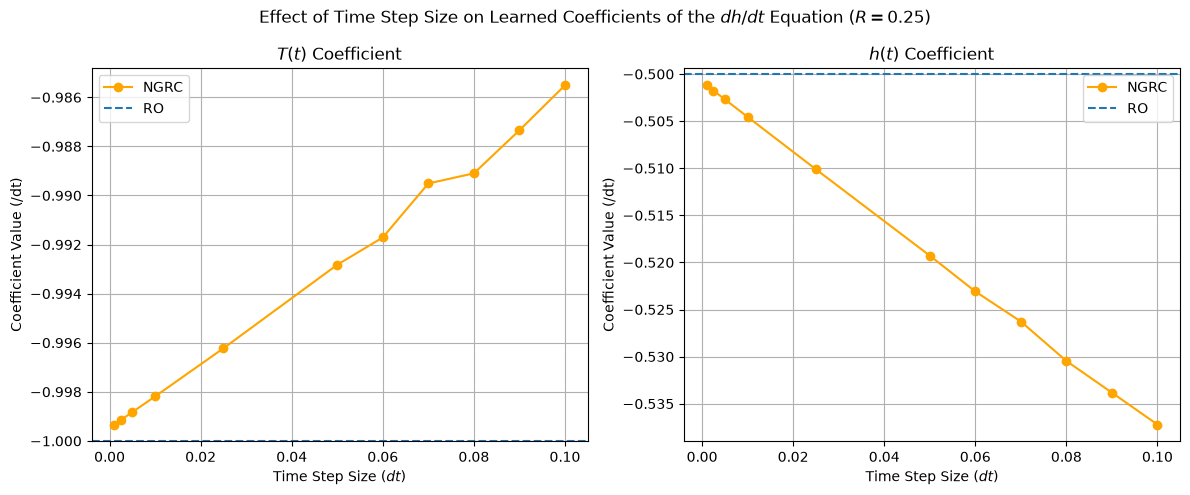

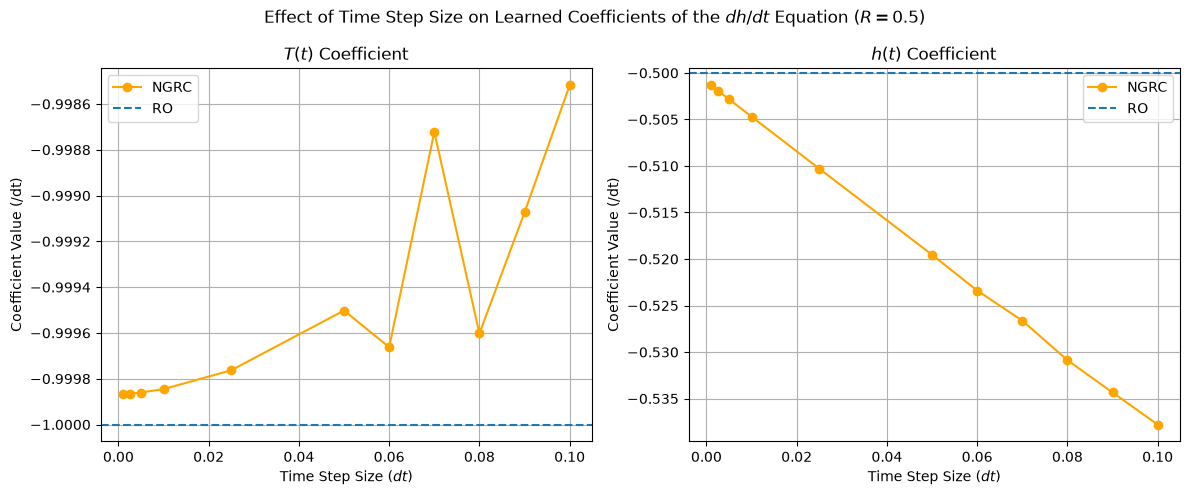

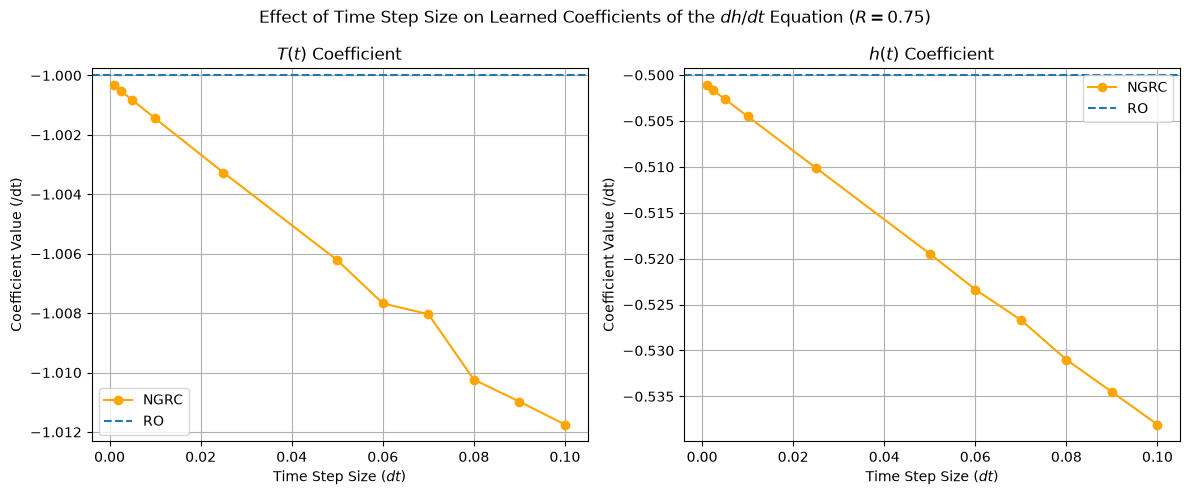

In [9]:
for R in R_values:

    weights_dh = weights_df[
        (weights_df["equation"] == "dh")
        & (weights_df["R"] == R)
    ].copy()

    weights_dh["NGRC T(t)/dt"] = (
        weights_dh["T(t)"] / weights_dh["dt"]
    )

    weights_dh["NGRC h(t)/dt"] = (
        weights_dh["h(t)"] / weights_dh["dt"]
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        sharex=True
    )

    # T coefficient

    axes[0].plot(
        weights_dh["dt"],
        weights_dh["NGRC T(t)/dt"],
        marker="o",
        color="orange",
        label="NGRC"
    )

    axes[0].axhline(
        y=-1.0,
        linestyle="--",
        label="RO"
    )

    axes[0].set_title(r"$T(t)$ Coefficient")
    axes[0].set_xlabel("Time Step Size ($dt$)")
    axes[0].set_ylabel("Coefficient Value (/dt)")
    axes[0].grid(True)
    axes[0].legend()

    # h coefficient

    axes[1].plot(
        weights_dh["dt"],
        weights_dh["NGRC h(t)/dt"],
        marker="o",
        color="orange",
        label="NGRC"
    )

    axes[1].axhline(
        y=-0.5,
        linestyle="--",
        label="RO"
    )

    axes[1].set_title(r"$h(t)$ Coefficient")
    axes[1].set_xlabel("Time Step Size ($dt$)")
    axes[1].set_ylabel("Coefficient Value (/dt)")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle(
        rf"Effect of Time Step Size on Learned Coefficients of the $dh/dt$ Equation ($R={R}$)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{IMAGE_DIR}/dh_coefficients_vs_dt_R{str(R).replace('.','')}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

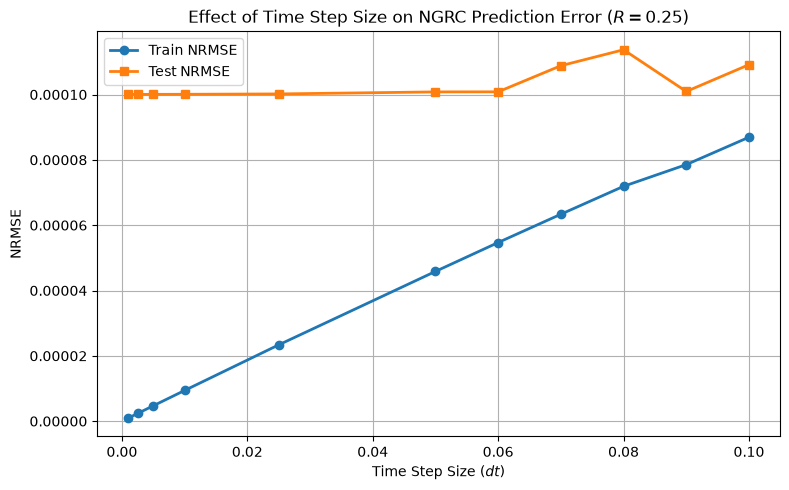

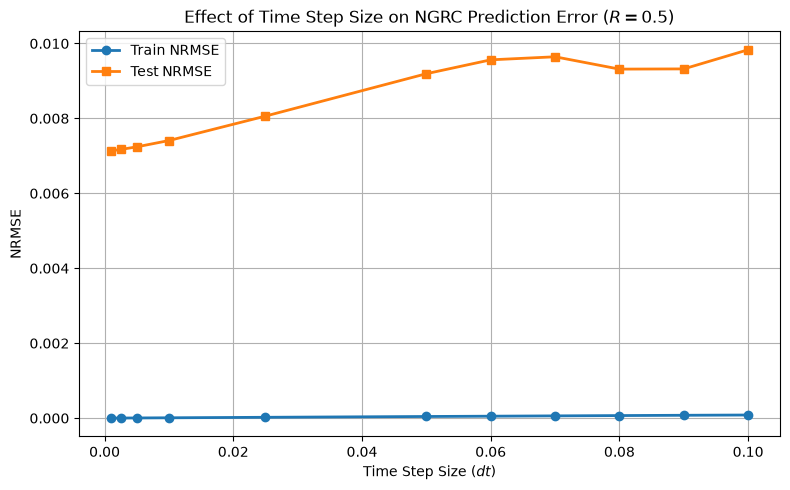

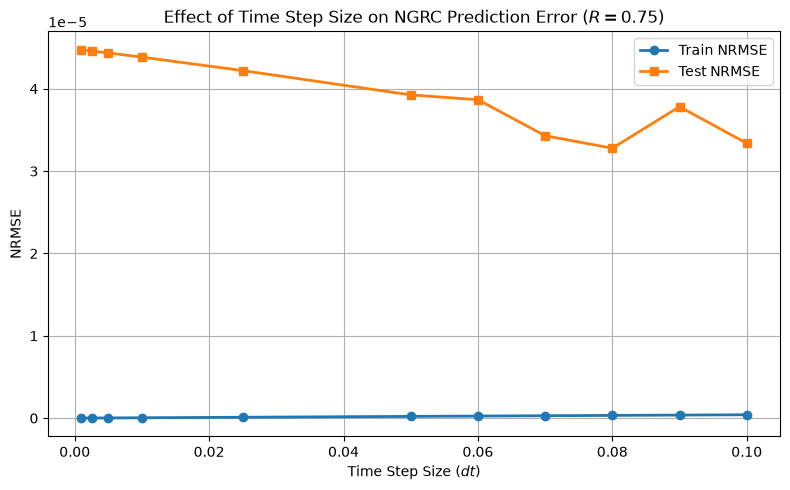

In [10]:
for R in R_values:

    summary = pd.DataFrame([
        {
            "dt": r["dt"],
            "train_nrmse": r["train_nrmse"],
            "test_nrmse": r["test_nrmse"],
        }
        for r in all_results
        if r["R"] == R
    ])

    summary = summary.sort_values("dt")

    plt.figure(figsize=(8, 5))

    plt.plot(
        summary["dt"],
        summary["train_nrmse"],
        marker="o",
        linewidth=2,
        label="Train NRMSE",
    )

    plt.plot(
        summary["dt"],
        summary["test_nrmse"],
        marker="s",
        linewidth=2,
        label="Test NRMSE",
    )

    plt.xlabel("Time Step Size ($dt$)")
    plt.ylabel("NRMSE")

    plt.title(
        rf"Effect of Time Step Size on NGRC Prediction Error ($R={R}$)"
    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{IMAGE_DIR}/nrmse_vs_dt_R{str(R).replace('.','')}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

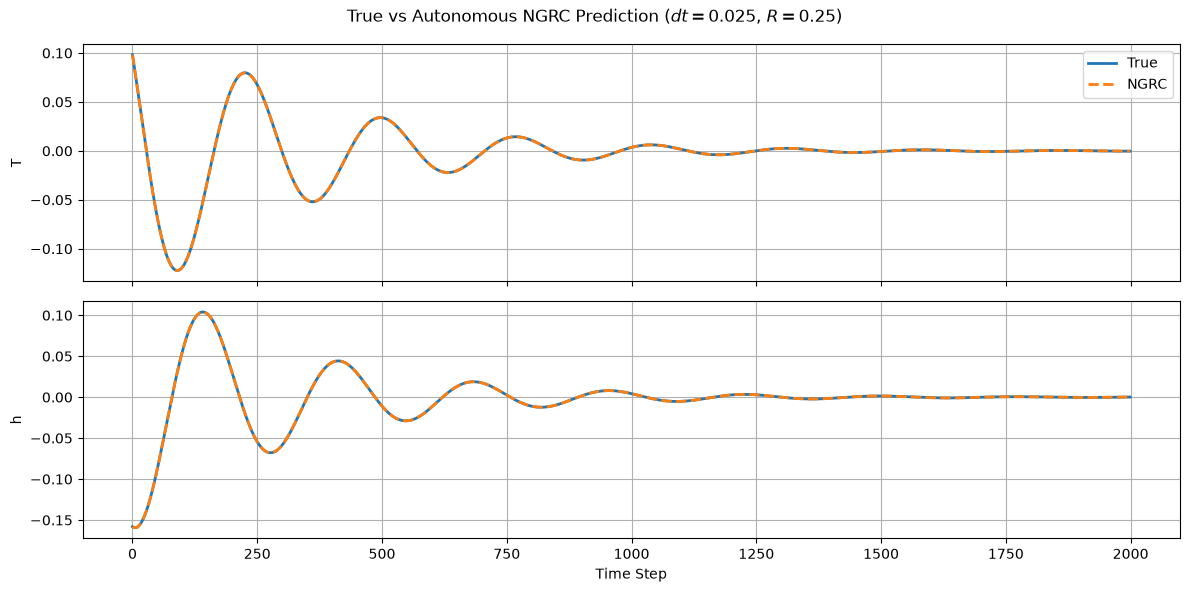

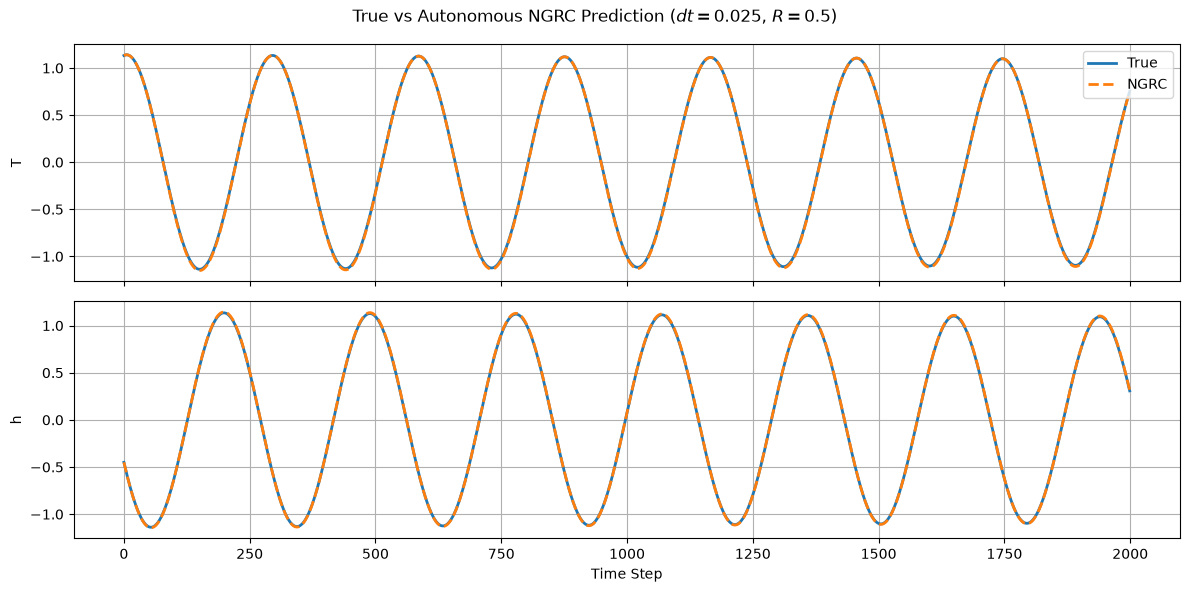

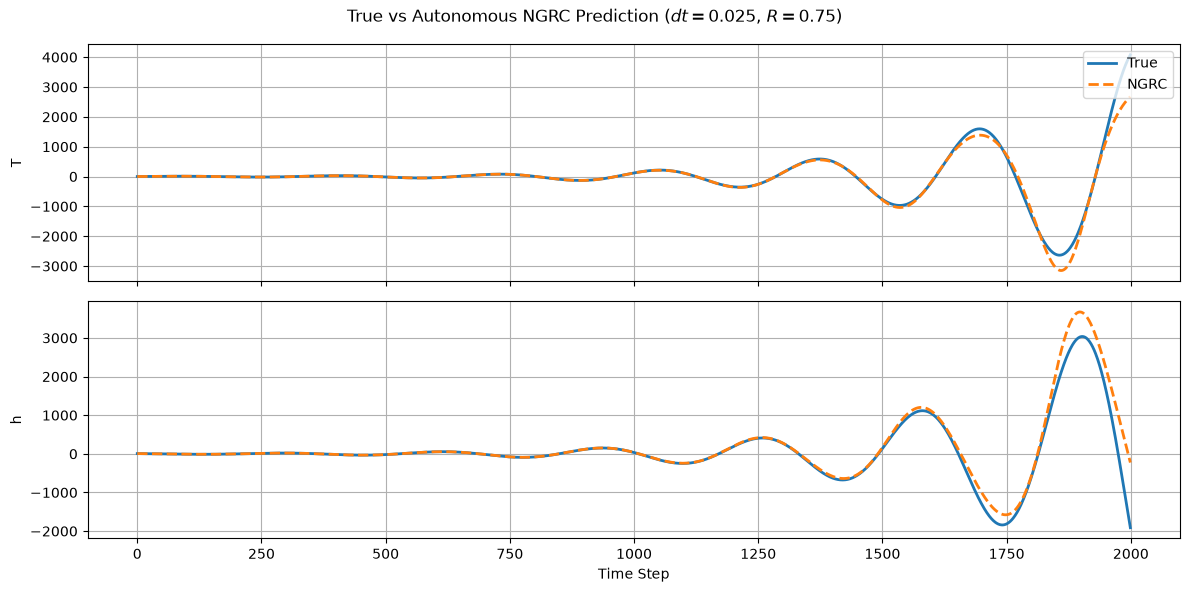

In [11]:
for R in R_values:

    r = next(
        r for r in all_results
        if r["R"] == R
        and r["dt"] == 0.025
    )

    true = r["true_test"]
    pred = r["x_test"]

    n = pred.shape[1]

    fig, axs = plt.subplots(
        2, 1,
        figsize=(12, 6),
        sharex=True
    )

    names = ["T", "h"]

    for i in range(2):

        axs[i].plot(
            true[i, :n],
            linewidth=2,
            label="True"
        )

        axs[i].plot(
            pred[i, :n],
            "--",
            linewidth=2,
            label="NGRC"
        )

        axs[i].set_ylabel(names[i])

        axs[i].grid(True)

    axs[0].legend(
        loc="upper right"
    )

    axs[-1].set_xlabel(
        "Time Step"
    )

    plt.suptitle(
        rf"True vs Autonomous NGRC Prediction ($dt=0.025$, $R={R}$)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{IMAGE_DIR}/true_vs_ngrc_R{str(R).replace('.','')}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

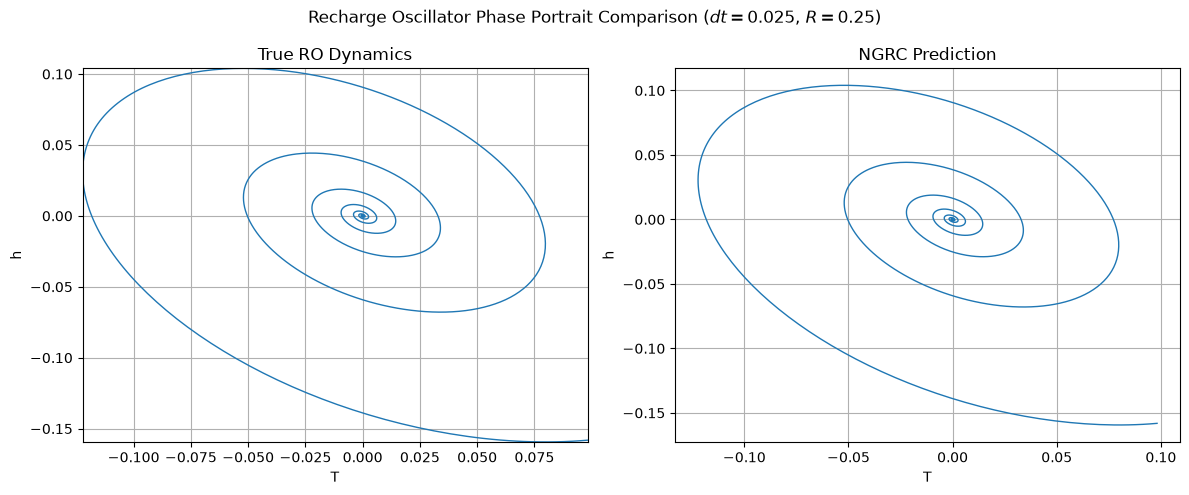

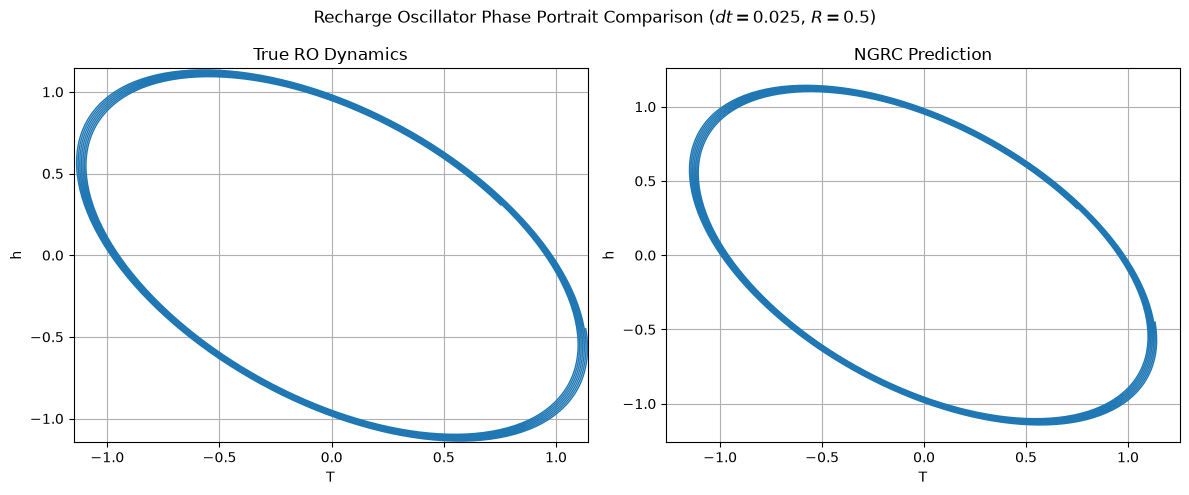

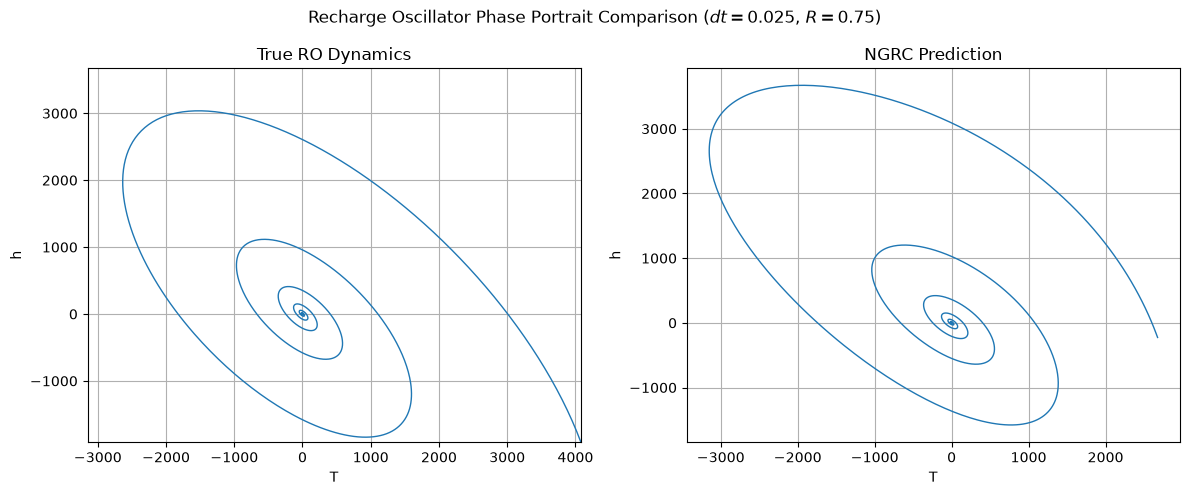

In [12]:
for R in R_values:

    r = next(
        r for r in all_results
        if r["R"] == R
        and r["dt"] == 0.025
    )

    true = r["true_test"]
    pred = r["x_test"]

    fig, axs = plt.subplots(
        1, 2,
        figsize=(12, 5),
    )

    xmin = min(
        true[0].min(),
        pred[0].min()
    )

    xmax = max(
        true[0].max(),
        pred[0].max()
    )

    ymin = min(
        true[1].min(),
        pred[1].min()
    )

    ymax = max(
        true[1].max(),
        pred[1].max()
    )

    # True RO dynamics

    axs[0].plot(
        true[0, :],
        true[1, :],
        linewidth=1,
    )

    axs[0].set_title(
        "True RO Dynamics"
    )

    axs[0].set_xlabel("T")

    axs[0].set_ylabel("h")

    axs[0].set_xlim(
        xmin,
        xmax
    )

    axs[0].set_ylim(
        ymin,
        ymax
    )

    axs[0].grid(True)

    # NGRC prediction

    axs[1].plot(
        pred[0, :],
        pred[1, :],
        linewidth=1,
    )

    axs[1].set_title(
        "NGRC Prediction"
    )

    axs[1].set_xlabel("T")

    axs[1].set_ylabel("h")



    axs[1].grid(True)

    plt.suptitle(
        rf"Recharge Oscillator Phase Portrait Comparison ($dt=0.025$, $R={R}$)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{IMAGE_DIR}/phase_portrait_comparison_R{str(R).replace('.','')}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

In [13]:
factor_cols = labels[1:]

all_top3_dT = []

for R in R_values:

    weights_dT = weights_df[
        (weights_df["equation"] == "dT")
        & (weights_df["R"] == R)
    ].copy()

    rows = []

    for _, row in weights_dT.iterrows():

        dt = row["dt"]

        coeffs = row[factor_cols] / dt

        top3 = (
            coeffs.abs()
            .sort_values(ascending=False)
            .head(3)
        )

        rows.append({
            "R": R,

            "dt": dt,

            "1st": (
                f"{top3.index[0]} "
                f"({coeffs[top3.index[0]]:.2f})"
            ),

            "2nd": (
                f"{top3.index[1]} "
                f"({coeffs[top3.index[1]]:.2f})"
            ),

            "3rd": (
                f"{top3.index[2]} "
                f"({coeffs[top3.index[2]]:.2f})"
            ),
        })

    top3_dT = (
        pd.DataFrame(rows)
        .sort_values("dt")
    )

    all_top3_dT.append(top3_dT)

top3_dT = pd.concat(
    all_top3_dT,
    ignore_index=True
)

top3_dT

,R,dt,1st,2nd,3rd
0,0.25,0.0010,h(t) (1.00),T(t) (0.25),T(t)*h(t) (0.00)
1,0.25,0.0025,h(t) (1.00),T(t) (0.25),T(t)*h(t) (0.00)
2,0.25,0.0050,h(t) (1.00),T(t) (0.25),T(t)*h(t) (0.00)
3,0.25,0.0100,h(t) (1.00),T(t) (0.24),T(t)*h(t) (0.00)
4,0.25,0.0250,h(t) (1.00),T(t) (0.24),T(t)*h(t) (0.00)
5,0.25,0.0500,h(t) (0.99),T(t) (0.23),T(t)*h(t) (0.00)
6,0.25,0.0600,h(t) (0.99),T(t) (0.22),T(t)*h(t) (0.00)
7,0.25,0.0700,h(t) (0.99),T(t) (0.22),T(t)*h(t) (0.00)
8,0.25,0.0800,h(t) (0.99),T(t) (0.21),T(t)*h(t) (0.00)
9,0.25,0.0900,h(t) (0.99),T(t) (0.21),T(t)*h(t) (0.00)
